# Validation against PRODES

How far can the alerts be trusted? This notebook compares them with PRODES, the annual deforestation map produced by INPE for the Brazilian Amazon. It reads the results of `01_detection.ipynb` from `outputs/` and does not download any satellite data. The PRODES file has to be downloaded once by hand from TerraBrasilis (Legal Amazon, "Complete PRODES in vector format") and placed in `data/`.

PRODES is a reference with its own rules. It maps only clear-cut of primary forest, in patches of at least 6.25 hectares, and once an area is recorded as deforested it is never mapped again. The alerts measure something broader: any strong drop in vegetation between the two periods. Part of the disagreement between the two therefore comes from their definitions.

In [26]:
%load_ext autoreload
%autoreload 2

import json
from datetime import date
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray
import contextily as cx
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from shapely.geometry import box

from utils import to_mask, polygon_coverage, mean_value_in_polygon

PRODES_PATH = Path("data/prodes_amazonia_legal_v20260717.gpkg")
YEARS_COMPARED = (2019, 2023)       # PRODES years that fall between the two image windows
FOUND_THRESHOLD = 0.5               # share of a PRODES polygon the alerts must cover

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. The analysis grid

Every comparison in this notebook happens on the grid of the NDVI change raster written by the detection notebook. Its values are not used here, only its shape, position and projection (UTM): they define the pixels on which both PRODES and the alerts are drawn.

The grid is slightly larger than the bounding box in degrees used to download the imagery, because a rectangle in UTM has to cover a rectangle in latitude and longitude. To compare like with like, every layer is clipped to the footprint of the grid itself, and PRODES is read over that same footprint.

In [27]:
grid = rioxarray.open_rasterio(OUTPUT_DIR / "ndvi_change.tif").squeeze("band", drop=True)
footprint = gpd.GeoDataFrame(geometry=[box(*grid.rio.bounds())], crs=grid.rio.crs)

print("grid:", grid.rio.crs, grid.shape, f"{footprint.area.iloc[0] / 10_000:.0f} ha")

grid: EPSG:32720 (1108, 1100) 12188 ha


## 2. Load PRODES over the grid

The full PRODES file covers the whole Legal Amazon. Reading it with a bounding box returns only the polygons that touch it, which is fast thanks to the spatial index of the GeoPackage. The bounding box is the grid footprint converted to SIRGAS 2000 (EPSG:4674), the system PRODES is distributed in.

In [28]:
print(gpd.list_layers(PRODES_PATH))

read_bbox = grid.rio.transform_bounds("EPSG:4674")
prodes = gpd.read_file(PRODES_PATH, layer="yearly_deforestation", bbox=read_bbox)
print(len(prodes), "polygons touch the grid")

                             name geometry_type
0  accumulated_deforestation_2007       Unknown
1            yearly_deforestation       Unknown
2                       no_forest       Unknown
3                     hydrography       Unknown
4                        residual       Unknown
106 polygons touch the grid


## 3. A first look at the data

PRODES is distributed in SIRGAS 2000 (EPSG:4674), the official geodetic system of Brazil. Like EPSG:4326 it is in degrees and the two differ by less than a metre here, but geopandas needs both layers in the same system before combining them.

The count of polygons per year shows when the AOI was cleared: 76 polygons date from 2008 to 2018 and only 30 from 2019 to 2023. Most of the deforestation in this area happened before the baseline period.

In [29]:
print(prodes.crs)
print(prodes.columns.tolist())
print(len(prodes), "polygons")

EPSG:4674
['state', 'path_row', 'main_class', 'class_name', 'sub_class', 'def_cloud', 'julian_day', 'image_date', 'year', 'area_km', 'scene_id', 'source', 'satellite', 'sensor', 'uuid', 'geometry']
106 polygons


In [30]:
prodes["year"].value_counts().sort_index()

year
2008     4
2009     4
2010     3
2011     4
2012     2
2013     9
2014     4
2015     8
2016    19
2017    12
2018     7
2019     7
2020     4
2021     9
2022     6
2023     4
Name: count, dtype: int64

## 4. Which years to compare

A PRODES year runs from August to July, so PRODES 2019 covers August 2018 to July 2019. The baseline scenes are from July to September 2018 and the recent ones from June to September 2023.

PRODES 2018 is left out: those areas were already cleared in the baseline scenes, so they show no change between the two periods. The years 2019 to 2023 are kept, as they fall between the two windows.

In [31]:
prodes_change = prodes[prodes["year"].between(*YEARS_COMPARED)]
print(len(prodes_change), "polygons from", YEARS_COMPARED[0], "to", YEARS_COMPARED[1])

30 polygons from 2019 to 2023


## 5. Reproject and clip to the grid

The polygons are reprojected to the CRS of the grid, so that areas come out in square metres, and clipped to its footprint, so that only the parts inside the analysed area count. The clipped layer is also saved to a small file, so the large PRODES download is not needed to look at it again.

In [32]:
prodes_utm = gpd.clip(prodes_change.to_crs(grid.rio.crs), footprint)
prodes_utm.to_file("data/prodes_aoi.gpkg", layer="deforestation_2019_2023", driver="GPKG")
print(len(prodes_utm), "polygons inside the grid,",
      f"{prodes_utm.area.sum() / 10_000:.1f} ha")

30 polygons inside the grid, 415.8 ha


## 6. Load the alerts

The alerts produced by `01_detection.ipynb`: areas where NDVI dropped by more than the threshold, confirmed by a rise in bare soil, larger than half a hectare and not on water.

In [33]:
alerts = gpd.read_file(OUTPUT_DIR / "deforestation_alerts.geojson")
alerts_utm = alerts.to_crs(grid.rio.crs)
print(len(alerts), "alerts,", f"{alerts_utm.area.sum() / 10_000:.1f} ha")

129 alerts, 1050.3 ha


## 7. A visual comparison

PRODES polygons in yellow and alerts in red, over a satellite basemap. The basemap is a mosaic of unknown dates and is there only for orientation: it shows neither 2018 nor 2023.

Before computing any metric, three things are worth reading off the map: how many PRODES polygons contain an alert, how many alerts have no PRODES polygon nearby, and what kind of land those isolated alerts sit on.

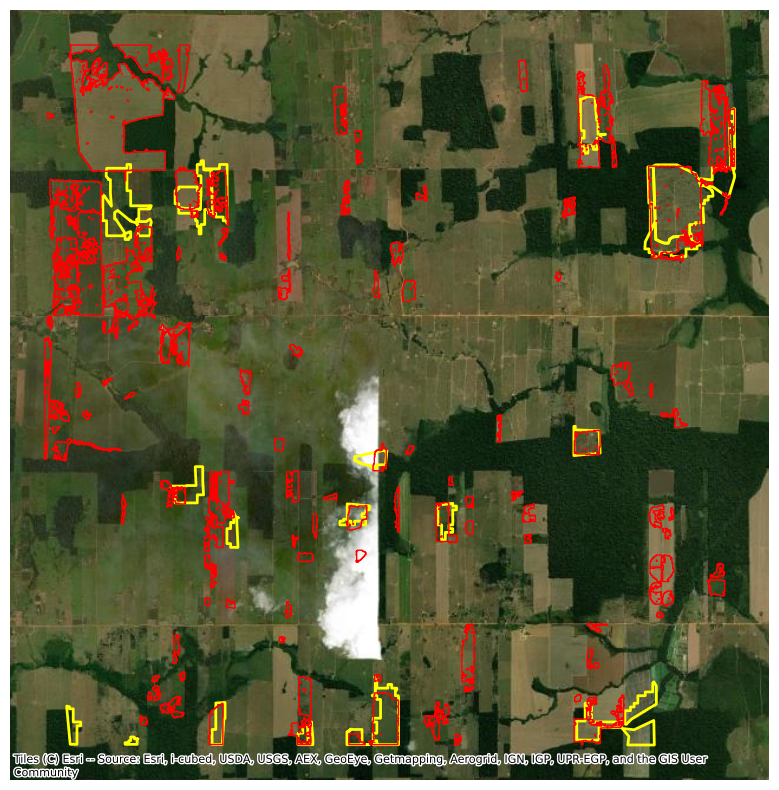

In [34]:
fig, ax = plt.subplots(figsize=(10, 10))
prodes_utm.to_crs(epsg=3857).plot(ax=ax, facecolor="none", edgecolor="yellow", linewidth=2)
alerts_utm.to_crs(epsg=3857).plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1)
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery)
ax.set_axis_off()
plt.savefig(FIGURE_DIR / "prodes_vs_alerts.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. From polygons to masks

Each layer is rasterized: every pixel of the grid gets 1 if it falls inside a polygon and 0 otherwise. This is the reverse of the step that turned the change map into polygons in the detection notebook.

As a check, the area counted from the mask (pixels × 100 m²) should match the area measured on the polygons. A large gap between the two would mean the layers and the grid are not in the same reference system.

In [35]:
prodes_bool = to_mask(prodes_utm, grid)
alerts_bool = to_mask(alerts_utm, grid)

print(f"PRODES: {prodes_bool.sum() / 100:7.1f} ha from the mask, {prodes_utm.area.sum() / 10_000:7.1f} ha from the polygons")
print(f"alerts: {alerts_bool.sum() / 100:7.1f} ha from the mask, {alerts_utm.area.sum() / 10_000:7.1f} ha from the polygons")

PRODES:   413.9 ha from the mask,   415.8 ha from the polygons
alerts:  1050.3 ha from the mask,  1050.3 ha from the polygons


## 9. Agreement, pixel by pixel

Every pixel falls into one of four cases: flagged by both, by the alerts only, by PRODES only, or by neither. From these counts:

- **Precision**: of everything the alerts flag, how much PRODES also maps.
- **Recall**: of everything PRODES maps, how much the alerts find.
- **F1**: a single score that balances the two.

Accuracy is reported too, but it is not a useful measure here. Most of the AOI did not change according to either source, and those pixels count as correct, so a method that never flagged anything would still score very high.

The alerts cover a much larger area than PRODES, which puts a ceiling on precision before any comparison is made: the pixels in agreement can never be more than the PRODES pixels.

In [36]:
true_pos = (alerts_bool & prodes_bool).sum()
false_pos = (alerts_bool & ~prodes_bool).sum()
false_neg = (~alerts_bool & prodes_bool).sum()
true_neg = (~alerts_bool & ~prodes_bool).sum()

precision = true_pos / (true_pos + false_pos)
recall = true_pos / (true_pos + false_neg)
f1 = 2 * precision * recall / (precision + recall)
accuracy = (true_pos + true_neg) / prodes_bool.size

print(f"true positives:  {true_pos / 100:8.1f} ha")
print(f"false positives: {false_pos / 100:8.1f} ha")
print(f"false negatives: {false_neg / 100:8.1f} ha")
print()
print(f"precision: {precision:.1%}")
print(f"recall:    {recall:.1%}")
print(f"F1:        {f1:.1%}")
print(f"accuracy:  {accuracy:.1%}")

true positives:     242.1 ha
false positives:    808.2 ha
false negatives:    171.8 ha

precision: 23.0%
recall:    58.5%
F1:        33.1%
accuracy:  92.0%


## 10. Where the two agree and where they do not

The same four cases, drawn on the map. Green is agreement, red is flagged by the alerts only, blue is mapped by PRODES only.

The shape of the disagreement matters more than its amount. A thin blue rim around a green patch means the two sources outline the same clearing slightly differently, which is expected when one works at 30 m and the other at 10 m. A solid blue patch is a clearing the alerts missed entirely. Red areas far from any green are either false alarms or real changes that fall outside what PRODES records, and the next section tries to tell the two apart.

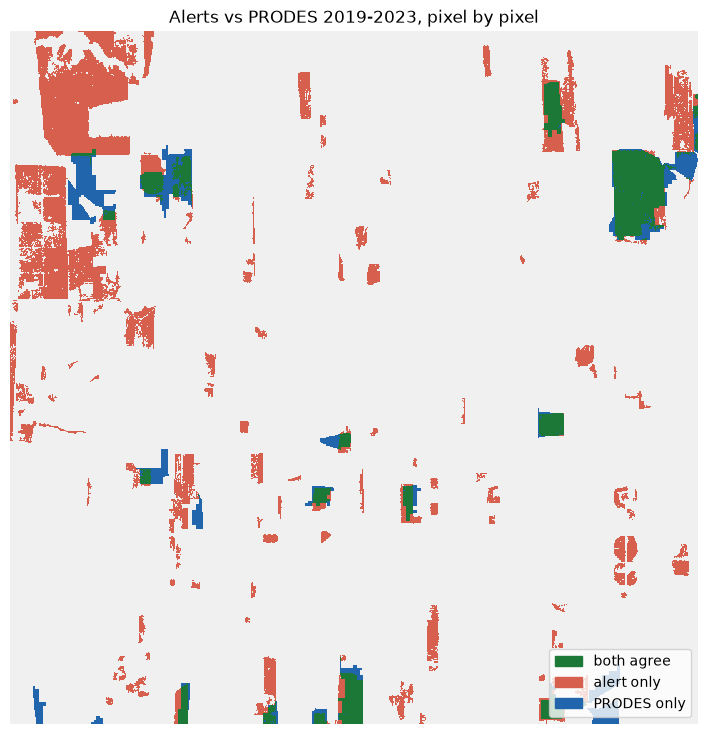

In [37]:
classes = np.zeros(prodes_bool.shape, dtype="uint8")
classes[alerts_bool & prodes_bool] = 1     # agreement
classes[alerts_bool & ~prodes_bool] = 2    # alert only
classes[~alerts_bool & prodes_bool] = 3    # PRODES only

colors = ["#f0f0f0", "#1b7837", "#d6604d", "#2166ac"]
labels = ["neither", "both agree", "alert only", "PRODES only"]

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(classes, cmap=ListedColormap(colors), interpolation="nearest")
ax.legend(handles=[Patch(color=c, label=l) for c, l in zip(colors[1:], labels[1:])],
          loc="lower right")
ax.set_title("Alerts vs PRODES 2019-2023, pixel by pixel")
ax.set_axis_off()
plt.savefig(FIGURE_DIR / "prodes_confusion_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Land that PRODES no longer watches

PRODES records an area once. After that, nothing that happens there is mapped again. To know where PRODES can still report new deforestation, all the land recorded before the study period is needed: the accumulated deforestation up to 2007 and the yearly polygons from 2008 to 2018.

Two other layers, non-forest vegetation and hydrography, would be excluded for the same reason, but both are empty over this AOI. PRODES maps only large water bodies, and the small ponds found in the detection notebook are below its scale.

In [38]:
accumulated = gpd.read_file(PRODES_PATH, layer="accumulated_deforestation_2007", bbox=read_bbox)
no_forest = gpd.read_file(PRODES_PATH, layer="no_forest", bbox=read_bbox)
hydrography = gpd.read_file(PRODES_PATH, layer="hydrography", bbox=read_bbox)
earlier = prodes[prodes["year"] < YEARS_COMPARED[0]]

for name, layer in [("accumulated to 2007", accumulated), ("cleared 2008-2018", earlier),
                    ("no forest", no_forest), ("hydrography", hydrography)]:
    print(f"{name}: {len(layer)} polygons")

accumulated to 2007: 5 polygons
cleared 2008-2018: 76 polygons
no forest: 0 polygons
hydrography: 0 polygons


## 12. A mask of land no longer forest by 2018

All the layers are drawn on the grid and merged: a pixel belongs to the mask if it was cleared at any time before 2019, or if it is not forest at all. When it happened does not matter here, only that PRODES had already recorded it.

The cleared layers should never overlap, since the same area is not recorded twice. An overlap of zero confirms this and shows that the layers line up on the grid.

In [39]:
accumulated_bool = to_mask(accumulated, grid)
earlier_bool = to_mask(earlier, grid)
not_forest_2018 = accumulated_bool | earlier_bool | to_mask(no_forest, grid) | to_mask(hydrography, grid)

n_acc, n_rec = accumulated_bool.sum(), earlier_bool.sum()
print(f"accumulated to 2007: {n_acc} pixels, cleared 2008-2018: {n_rec} pixels")
print("overlap:", int((accumulated_bool & earlier_bool).sum()))
print(f"not forest in 2018: {not_forest_2018.mean():.1%} of the grid")

accumulated to 2007: 848768 pixels, cleared 2008-2018: 95483 pixels
overlap: 0
not forest in 2018: 77.5% of the grid


## 13. Where do the false positives fall?

The alerts with no matching PRODES polygon are split in two. Those inside the mask sit on land cleared before 2019, where PRODES cannot confirm or reject anything. Those outside sit on what PRODES considers standing forest, and are the real disagreements between the two sources.

As a check, no PRODES polygon of 2019 to 2023 should fall inside the mask.

In [40]:
fp_mask = alerts_bool & ~prodes_bool
fp_cleared = fp_mask & not_forest_2018       # on land already cleared
fp_forest = fp_mask & ~not_forest_2018       # on standing forest

print(f"false positives:            {fp_mask.sum() / 100:8.1f} ha")
print(f"  on land already cleared:  {fp_cleared.sum() / 100:8.1f} ha "
      f"({fp_cleared.sum() / fp_mask.sum():.1%})")
print(f"  on standing forest:       {fp_forest.sum() / 100:8.1f} ha "
      f"({fp_forest.sum() / fp_mask.sum():.1%})")
print("PRODES pixels inside the mask:", (prodes_bool & not_forest_2018).sum())

false positives:               808.2 ha
  on land already cleared:     753.9 ha (93.3%)
  on standing forest:           54.3 ha (6.7%)
PRODES pixels inside the mask: 0


## 14. Precision on equal terms

The first precision compared alerts drawn over the whole AOI with a reference that can only report on the part still forested in 2018. Restricting the alerts to that same part compares the two sources over the same ground.

Recall is unchanged, since the mask removes alerts and leaves the PRODES polygons untouched.

In [41]:
alerts_forest = alerts_bool & ~not_forest_2018
tp_forest = (alerts_forest & prodes_bool).sum()

precision_forest = tp_forest / alerts_forest.sum()

print(f"precision, whole AOI:   {precision:.1%}")
print(f"precision, forest only: {precision_forest:.1%}")
print(f"recall:                 {recall:.1%}")

precision, whole AOI:   23.0%
precision, forest only: 81.7%
recall:                 58.5%


## 15. The same map, with the cleared land set apart

The alert-only pixels are now shown in two colours: orange where the land had already been cleared, red where PRODES sees standing forest. The red that remains is what still needs an explanation.

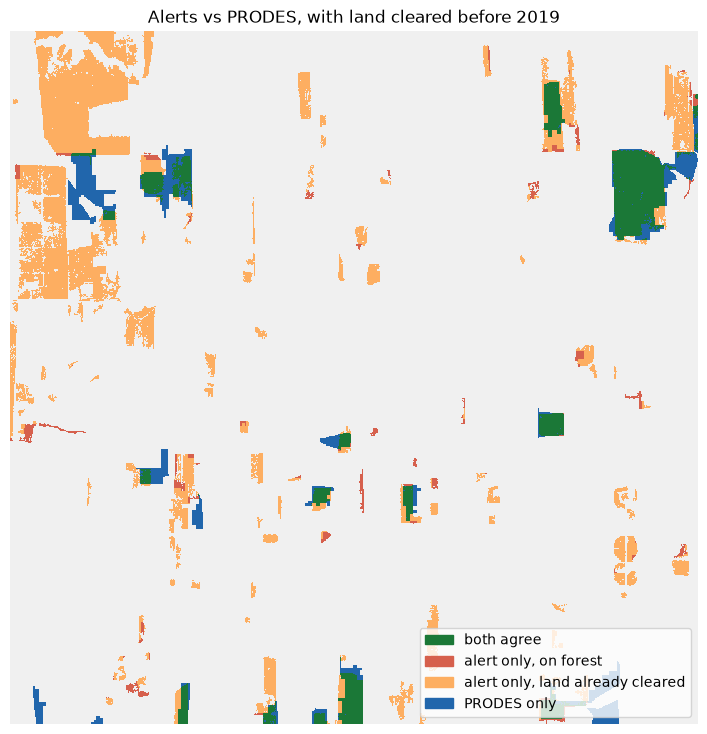

In [42]:
classes = np.zeros(alerts_bool.shape, dtype="uint8")
classes[alerts_bool & prodes_bool] = 1     # both agree
classes[fp_forest] = 2                     # alert only, on forest
classes[fp_cleared] = 3                    # alert only, on land already cleared
classes[~alerts_bool & prodes_bool] = 4    # PRODES only

colors = ["#f0f0f0", "#1b7837", "#d6604d", "#fdae61", "#2166ac"]
labels = ["neither", "both agree", "alert only, on forest",
          "alert only, land already cleared", "PRODES only"]

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(classes, cmap=ListedColormap(colors), interpolation="nearest")
ax.legend(handles=[Patch(color=c, label=l) for c, l in zip(colors[1:], labels[1:])],
          loc="lower right")
ax.set_title("Alerts vs PRODES, with land cleared before 2019")
ax.set_axis_off()
plt.savefig(FIGURE_DIR / "prodes_confusion_map_4classes.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. From pixels to polygons: how much of each clearing was found

Recall measured pixel by pixel mixes two different things: a clearing the alerts missed entirely, and a clearing they found with a smaller outline. For anyone using the alerts the first matters far more, since an alert in the right place still sends someone to look.

Each PRODES polygon is intersected with the alerts, and the overlapping area is divided by the area of the polygon. The alerts are first merged into a single geometry, so that land covered by two alerts is not counted twice. The result is one number per polygon, between 0 and 1: the share of that clearing the alerts cover.

In [43]:
prodes_utm["area_ha"] = prodes_utm.geometry.area / 10_000
prodes_utm["coverage"] = polygon_coverage(prodes_utm, alerts_utm)

prodes_utm["coverage"].describe()

count    30.000000
mean      0.483735
std       0.360757
min       0.000000
25%       0.081586
50%       0.557530
75%       0.837000
max       0.986389
Name: coverage, dtype: float64

## 17. Found, partly found, missed

Each polygon is placed in one of three groups. It counts as found when the alerts cover at least half of it, as partly found when they cover something, and as missed when they cover nothing at all. The half-way cut-off is a choice, not a standard, and moving it shifts polygons between the first two groups.

In [44]:
prodes_utm["detection"] = np.select(
    [prodes_utm["coverage"] >= FOUND_THRESHOLD, prodes_utm["coverage"] > 0],
    ["found", "partial"],
    default="missed",
)
prodes_utm["detection"].value_counts()

detection
found      16
partial     9
missed      5
Name: count, dtype: int64

## 18. Detection by year of clearing

The comparison uses only two snapshots, 2018 and 2023. Land cleared in 2019 may be covered by grass or regrowth four years later, so its NDVI has partly recovered and the drop against 2018 is smaller. Land cleared in 2023 is still bare. If this is what happens, older clearings should be found less often than recent ones.

year
2019    0.66
2020    0.27
2021    0.48
2022    0.29
2023    0.70
Name: coverage, dtype: float64

detection  found  missed  partial
year                             
2019           5       0        2
2020           1       2        1
2021           5       1        3
2022           2       2        2
2023           3       0        1


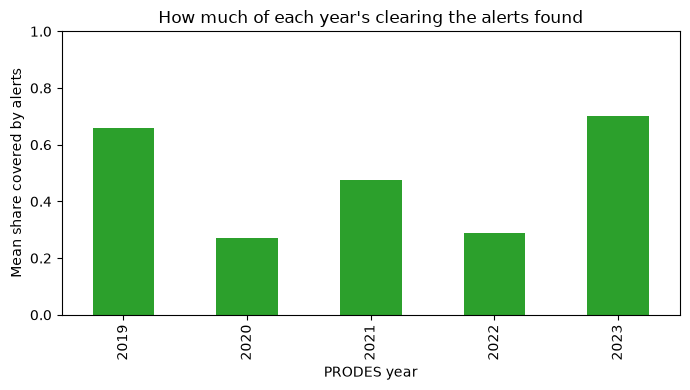

In [45]:
print(prodes_utm.groupby("year")["coverage"].mean().round(2))
print()
print(pd.crosstab(prodes_utm["year"], prodes_utm["detection"]))

ax = prodes_utm.groupby("year")["coverage"].mean().plot.bar(figsize=(7, 4), color="tab:green")
ax.set_ylabel("Mean share covered by alerts")
ax.set_xlabel("PRODES year")
ax.set_ylim(0, 1)
ax.set_title("How much of each year's clearing the alerts found")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "detection_by_year.png", dpi=150)
plt.show()

## 19. Detection by size

Each point is a PRODES polygon, placed by its area and by the share the alerts cover, and coloured by year. The dashed line marks the cut-off for a polygon to count as found.

PRODES maps only clearings of at least 6.25 hectares, while the alerts keep anything above half a hectare, so small size alone should not explain a miss. The plot shows whether missed polygons cluster at one end of the range or spread across it.

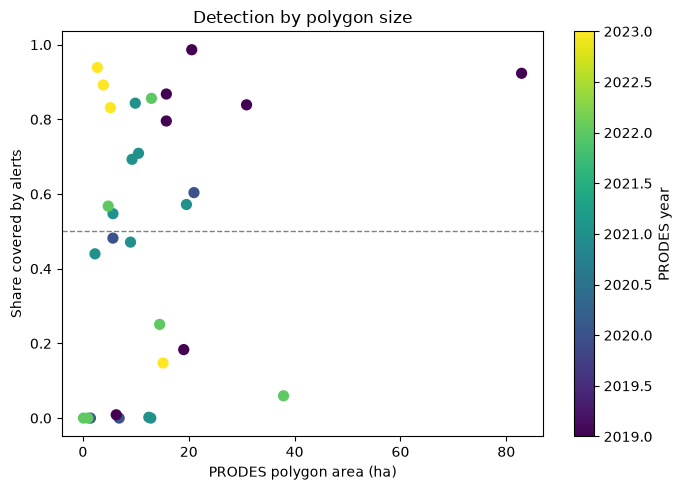

In [46]:
fig, ax = plt.subplots(figsize=(7, 5))
points = ax.scatter(prodes_utm["area_ha"], prodes_utm["coverage"],
                    c=prodes_utm["year"], cmap="viridis", s=50)
fig.colorbar(points, ax=ax, label="PRODES year")
ax.axhline(FOUND_THRESHOLD, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("PRODES polygon area (ha)")
ax.set_ylabel("Share covered by alerts")
ax.set_title("Detection by polygon size")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "detection_by_size.png", dpi=150)
plt.show()

## 20. What the alerts saw inside the missed clearings

For each polygon, the mean NDVI change inside it. For a polygon that was not found, this tells why. A mean close to the alert threshold of -0.25 means the drop was there but fell just short. A mean close to zero means the vegetation had largely recovered by 2023, and no threshold on a two-date difference would have caught it.

The table lists the polygons that were not fully found, from the least to the most covered.

In [47]:
prodes_utm["mean_ndvi_change"] = prodes_utm.geometry.apply(
    mean_value_in_polygon, args=(grid, prodes_utm.crs)
)

prodes_utm.groupby("detection")["mean_ndvi_change"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
detection,,,,,,,,
found,16.0,-0.330,0.079,-0.471,-0.386,-0.328,-0.281,-0.181
missed,5.0,-0.061,0.085,-0.176,-0.113,-0.029,-0.028,0.043
partial,9.0,-0.140,0.065,-0.264,-0.168,-0.114,-0.101,-0.047


In [48]:
not_found = prodes_utm[prodes_utm["detection"] != "found"]
not_found[["year", "area_ha", "coverage", "mean_ndvi_change", "detection"]] \
    .sort_values("coverage").round(3)

,year,area_ha,coverage,mean_ndvi_change,detection
12,2020,1.417,0.000,0.043,missed
9,2020,6.851,0.000,-0.028,missed
97,2021,12.829,0.000,-0.029,missed
69,2022,0.946,0.000,-0.176,missed
72,2022,0.114,0.000,-0.113,missed
102,2021,12.454,0.002,-0.047,partial
0,2019,6.294,0.009,-0.101,partial
89,2022,37.904,0.060,-0.093,partial
54,2023,15.142,0.147,-0.168,partial
76,2019,19.050,0.183,-0.111,partial


## 21. Late additions to PRODES

The residual layer holds deforestation from earlier years that PRODES missed at first and mapped later, during a revision. Its year column most likely records when the area was added, not when it was cleared, so it cannot simply be merged into the reference by year. It is reported here as a check: a residual polygon inside the grid is land PRODES considers cleared that the yearly layer does not show.

In [49]:
residual = gpd.read_file(PRODES_PATH, layer="residual", bbox=read_bbox)
residual = gpd.clip(residual.to_crs(grid.rio.crs), footprint)
print(len(residual), "residual polygons inside the grid,", f"{residual.area.sum() / 10_000:.1f} ha")
if len(residual) > 0:
    print(residual["year"].value_counts().sort_index().to_string())
    overlap_ha = (to_mask(residual, grid) & alerts_bool).sum() / 100
    print(f"of which covered by alerts: {overlap_ha:.1f} ha")

10 residual polygons inside the grid, 65.4 ha
year
2011    1
2015    2
2016    5
2021    1
2024    1
of which covered by alerts: 6.7 ha


## 22. Saving the results

The main numbers of this validation are written to `outputs/validation_metrics.json`. Other parts of the project, such as the assistant, can read them from there and report how far the alerts can be trusted, without running the validation again.

In [50]:
detection_counts = prodes_utm["detection"].value_counts()

metrics = {
    "generated_on": date.today().isoformat(),
    "reference": {
        "source": "INPE PRODES, Legal Amazon, yearly deforestation",
        "file": str(PRODES_PATH),
        "years_compared": list(YEARS_COMPARED),
        "minimum_mapped_area_ha": 6.25,
    },
    "pixel_level": {
        "precision_whole_aoi": round(float(precision), 3),
        "precision_forest_only": round(float(precision_forest), 3),
        "recall": round(float(recall), 3),
        "f1_whole_aoi": round(float(f1), 3),
    },
    "false_positives": {
        "total_ha": round(float(fp_mask.sum()) / 100, 1),
        "on_land_already_cleared_ha": round(float(fp_cleared.sum()) / 100, 1),
        "on_standing_forest_ha": round(float(fp_forest.sum()) / 100, 1),
        "share_on_land_already_cleared": round(float(fp_cleared.sum() / fp_mask.sum()), 3),
    },
    "grid": {
        "crs": str(grid.rio.crs),
        "area_ha": round(float(footprint.area.iloc[0]) / 10_000, 1),
        "share_not_forest_in_2018": round(float(not_forest_2018.mean()), 3),
    },
    "alerts": {
        "count": int(len(alerts)),
        "area_ha": round(float(alerts_utm.area.sum()) / 10_000, 1),
    },
    "polygon_level": {
        "found_threshold": FOUND_THRESHOLD,
        "n_polygons": int(len(prodes_utm)),
        "found": int(detection_counts.get("found", 0)),
        "partial": int(detection_counts.get("partial", 0)),
        "missed": int(detection_counts.get("missed", 0)),
        "mean_coverage_by_year": {
            str(year): round(float(value), 3)
            for year, value in prodes_utm.groupby("year")["coverage"].mean().items()
        },
        "mean_ndvi_change_by_group": {
            group: round(float(value), 3)
            for group, value in prodes_utm.groupby("detection")["mean_ndvi_change"].mean().items()
        },
    },
    "caveats": [
        "PRODES maps only the first clearing of primary forest, so alerts on land "
        "cleared before 2019 can be neither confirmed nor rejected by it.",
        "Precision on the whole AOI understates agreement; precision on forest only "
        "compares the two sources over the same ground.",
        "The comparison uses two dry-season snapshots, 2018 and 2023, so clearings "
        "that regrew in between can be missed.",
    ],
}

with open(OUTPUT_DIR / "validation_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))

{
  "generated_on": "2026-10-09",
  "reference": {
    "source": "INPE PRODES, Legal Amazon, yearly deforestation",
    "file": "data\\prodes_amazonia_legal_v20260717.gpkg",
    "years_compared": [
      2019,
      2023
    ],
    "minimum_mapped_area_ha": 6.25
  },
  "pixel_level": {
    "precision_whole_aoi": 0.23,
    "precision_forest_only": 0.817,
    "recall": 0.585,
    "f1_whole_aoi": 0.331
  },
  "false_positives": {
    "total_ha": 808.2,
    "on_land_already_cleared_ha": 753.9,
    "on_standing_forest_ha": 54.3,
    "share_on_land_already_cleared": 0.933
  },
  "grid": {
    "crs": "EPSG:32720",
    "area_ha": 12188.0,
    "share_not_forest_in_2018": 0.775
  },
  "alerts": {
    "count": 129,
    "area_ha": 1050.3
  },
  "polygon_level": {
    "found_threshold": 0.5,
    "n_polygons": 30,
    "found": 16,
    "partial": 9,
    "missed": 5,
    "mean_coverage_by_year": {
      "2019": 0.658,
      "2020": 0.271,
      "2021": 0.475,
      "2022": 0.289,
      "2023": 0.702
 